# 2. Генерация тестовых примеров и эталонное решение через CVXPY

In [94]:
import time
import pickle
import matplotlib.pyplot as plt

import numpy as np
import cvxpy as cp
import pandas as pd

from pathlib import Path
from scipy.linalg import svd
from typing import List, Dict


In [95]:
def entropy_objective(x: np.ndarray) -> float:
    if np.any(x <= 0):
        return np.inf
    return np.sum(x * np.log(x))


def recover_primal_from_dual(nu: np.ndarray, A: np.ndarray) -> np.ndarray:
    return np.exp(-A.T @ nu - 1)


def generate_full_rank_matrix(p: int, n: int, rng):
    while True:
        A = rng.standard_normal((p, n))
        if np.linalg.matrix_rank(A) == p:
            return A


def nullspace_basis(A: np.ndarray, tol=1e-12) -> np.ndarray:
    U, S, Vt = svd(A, full_matrices=True)
    rank = np.sum(S > tol * S[0])
    return Vt[rank:].T

In [96]:
def generate_test_problem(n: int, p: int, seed: int):
    rng = np.random.default_rng(seed)

    A = generate_full_rank_matrix(p, n, rng)

    x_feas = 0.5 + np.abs(rng.standard_normal(n))
    b = A @ x_feas

    N = nullspace_basis(A)

    return {
        'A': A,
        'b': b,
        'x_feas': x_feas,
        'N': N,
        'rng': rng
    }

In [97]:
def generate_feasible_starts(x_ref, N, num_starts, rng):
    starts = []
    n_p = N.shape[1]

    if n_p == 0:
        return [x_ref.copy() for _ in range(num_starts)]

    for _ in range(num_starts):
        z = rng.standard_normal(n_p)
        direction = N @ z

        alpha_max = np.inf
        mask = direction < 0
        if np.any(mask):
            alpha_max = np.min(x_ref[mask] / (-direction[mask])) * 0.5

        alpha = alpha_max * (0.2 + 0.6 * rng.random()) if np.isfinite(alpha_max) else 0

        x0 = x_ref + alpha * direction
        x0 = np.maximum(x0, 1e-8)

        starts.append(x0)

    return starts

In [98]:

def solve_primal(A, b):
    n = A.shape[1]
    x = cp.Variable(n)

    objective = cp.Minimize(cp.sum(-cp.entr(x)))
    constraints = [A @ x == b, x >= 1e-9]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.SCS, eps=1e-8, max_iters=10000)

    if x.value is None:
        raise RuntimeError("Primal solve failed")

    x_star = x.value
    f_star = entropy_objective(x_star)

    return x_star, f_star


def solve_dual(A, b):
    p = A.shape[0]
    nu = cp.Variable(p)

    phi_expr = b @ nu + cp.sum(cp.exp(-1 - A.T @ nu))

    prob = cp.Problem(cp.Minimize(phi_expr))
    prob.solve(solver=cp.SCS, eps=1e-8, max_iters=10000)

    if nu.value is None:
        raise RuntimeError("Dual solve failed")

    nu_star = nu.value

    # минимум -q
    phi_star = prob.value
    # максимум q
    q_star = -phi_star

    return nu_star, q_star, phi_star

In [99]:
def build_dataset(
    n_values=range(10, 101, 10),
    num_instances=5,
    num_starts=5,
    base_seed=1000,
    save_path=None,
):
    problems: List[Dict] = []
    global_problem_id = 0

    for n in n_values:
        p = n // 2

        print(f"\n=== n = {n}, p = {p} ===")

        for inst_id in range(num_instances):
            seed = base_seed * n + inst_id

            prob = generate_test_problem(n, p, seed)
            A = prob["A"]
            b = prob["b"]
            N = prob["N"]
            rng = prob["rng"]

            # CVXPY reference solutions
            x_star, f_star = solve_primal(A, b)
            nu_star, q_star, phi_star = solve_dual(A, b)

            x_dual = recover_primal_from_dual(nu_star, A)
            gap = abs(f_star - q_star)

            # primal feasible starts
            primal_starts = generate_feasible_starts(
                prob["x_feas"],
                N,
                num_starts,
                rng,
            )

            # dual starts
            dual_starts = [
                rng.standard_normal(p)
                for _ in range(num_starts)
            ]

            problems.append({
                "problem_id": global_problem_id,
                "n": n,
                "p": p,
                "instance_id": inst_id,
                "seed": seed,
                "A": A,
                "b": b,
                "N": N,
                "x_feas": prob["x_feas"],
                "x_star": x_star,
                "f_star": f_star,
                "nu_star": nu_star,
                "q_star": q_star,
                "phi_star": phi_star,
                "x_dual": x_dual,
                "duality_gap": gap,
                "primal_starts": primal_starts,
                "dual_starts": dual_starts,
            })

            print(f"Instance {inst_id}: gap = {gap:.2e}")
            global_problem_id += 1

    if save_path is not None:
        with open(save_path, "wb") as f:
            pickle.dump(problems, f)
        print(f"\nDataset saved to {save_path}")

    return problems

In [100]:
problems = build_dataset(
    n_values=range(10, 101, 10),
    num_instances=5,
    num_starts=5,
    save_path="entropy_problems.pkl",
)


=== n = 10, p = 5 ===
Instance 0: gap = 9.33e-11
Instance 1: gap = 2.07e-12
Instance 2: gap = 1.63e-12
Instance 3: gap = 1.51e-11
Instance 4: gap = 3.48e-12

=== n = 20, p = 10 ===
Instance 0: gap = 3.79e-13
Instance 1: gap = 1.07e-10
Instance 2: gap = 2.42e-11
Instance 3: gap = 1.94e-12
Instance 4: gap = 1.50e-10

=== n = 30, p = 15 ===
Instance 0: gap = 1.22e-11
Instance 1: gap = 7.41e-11
Instance 2: gap = 1.95e-13
Instance 3: gap = 5.84e-12
Instance 4: gap = 1.31e-12

=== n = 40, p = 20 ===
Instance 0: gap = 4.55e-13
Instance 1: gap = 2.25e-11
Instance 2: gap = 3.73e-13
Instance 3: gap = 2.25e-12
Instance 4: gap = 4.93e-11

=== n = 50, p = 25 ===
Instance 0: gap = 7.32e-13
Instance 1: gap = 4.82e-11
Instance 2: gap = 3.92e-12
Instance 3: gap = 2.53e-11
Instance 4: gap = 1.46e-10

=== n = 60, p = 30 ===
Instance 0: gap = 5.79e-12
Instance 1: gap = 2.78e-12
Instance 2: gap = 1.44e-10
Instance 3: gap = 3.15e-12
Instance 4: gap = 9.03e-12

=== n = 70, p = 35 ===
Instance 0: gap = 1.70e

In [101]:
def projected_gradient_direction(A, grad):
    n = A.shape[1]
    p = A.shape[0]

    KKT = np.block([
        [np.eye(n), A.T],
        [A, np.zeros((p, p))]
    ])

    rhs = -np.concatenate([grad, np.zeros(p)])

    sol = np.linalg.solve(KKT, rhs)
    d = sol[:n]

    return d

In [102]:
def dual_phi(nu, A, b):
    """
    phi(nu) = -q(nu)
    Минимизируемая двойственная функция.
    """
    return b @ nu + np.sum(np.exp(-1 - A.T @ nu))


def dual_phi_grad(nu, A, b):
    """
    Градиент phi(nu).
    """
    exp_term = np.exp(-1 - A.T @ nu)
    return b - A @ exp_term


def dual_phi_hess(nu, A):
    """
    Гессиан phi(nu).
    """
    exp_term = np.exp(-1 - A.T @ nu)
    return A @ np.diag(exp_term) @ A.T


In [103]:
EPS = 1e-4
MAX_ITER = 1000

In [104]:
def run_experiments(
    problems,
    primal_solver=None,
    dual_solver=None,
    method_name="method",
    save_dir="results",
    verbose=True,
):
    save_dir = Path(save_dir)
    save_dir.mkdir(exist_ok=True)
    results = []
    for problem in problems:
        problem_id = problem["problem_id"]
        n = problem["n"]
        instance_id = problem["instance_id"]
        num_starts = len(problem["primal_starts"])

        for start_id in range(num_starts):

            row = {
                "method": method_name,
                "problem_id": problem_id,
                "n": n,
                "p": problem["p"],
                "instance_id": instance_id,
                "start_id": start_id,
            }

            # PRIMAL
            if primal_solver is not None:
                x0 = problem["primal_starts"][start_id]

                t0 = time.time()
                x_sol, hist_p = primal_solver(problem, x0)
                time_p = time.time() - t0

                row.update({
                    "primal_iters": hist_p[-1]["iter"],
                    "primal_time": time_p,
                    "primal_final_error": hist_p[-1]["error"],
                    "primal_success": hist_p[-1]["error"] <= EPS,
                    "primal_history": hist_p,
                })

            # DUAL
            if dual_solver is not None:
                nu0 = problem["dual_starts"][start_id]

                t0 = time.time()
                nu_sol, hist_d = dual_solver(problem, nu0)
                time_d = time.time() - t0

                row.update({
                    "dual_iters": hist_d[-1]["iter"],
                    "dual_time": time_d,
                    "dual_final_error": hist_d[-1]["error"],
                    "dual_success": hist_d[-1]["error"] <= EPS,
                    "dual_history": hist_d,
                })

            results.append(row)

            if verbose:
                msg = (
                    f"method={method_name} | "
                    f"n={n} | inst={instance_id} | start={start_id}"
                )

                if primal_solver is not None:
                    msg += (
                        f" | primal it={row['primal_iters']}, "
                        f"time={row['primal_time']:.4f}, "
                        f"err={row['primal_final_error']:.2e}"
                    )

                if dual_solver is not None:
                    msg += (
                        f" | dual it={row['dual_iters']}, "
                        f"time={row['dual_time']:.4f}, "
                        f"err={row['dual_final_error']:.2e}"
                    )

                print(msg)

    # SAVE RESULTS
    pickle_path = save_dir / f"{method_name}_results.pkl"
    with open(pickle_path, "wb") as f:
        pickle.dump(results, f)
    print(f"\nPickle results saved to {pickle_path}")

    return results

# 4. По результатам вычислительных экспериментов для прямой и двойственной задач:

**a)** Для одного тестового примера при $n = 10$ и нескольких различных начальных точках постройте графики зависимости точности от числа итераций; 

**b)** для каждого $n \in {10, 20, . . . , 100}$ вычислите среднее время работы метода и среднее число итераций (усреднение проводится по всем тестовым примерам и всем начальным точкам); 

**c)** проведите сравнительный анализ демпфированного метода Ньютона, метода из пункта `3 b`, наиболее эффективного метода из пункта `3 c` и одного `ускоренного градиентного метода`; сформулируйте выводы по результатам сравнения.

---
Скопировала из 2 лабы 


### Метод момента Нестерова

**Константы:**

$h = \frac{1}{L}$ - градиентный шаг оптимизации

$\tau = \frac{\sqrt{L} - \sqrt{\mu}}{\sqrt{L} + \sqrt{\mu}}$ - в нашем случае $\mu = 0$ всегда, поэтому $\tau = 1$ 

**Алгоритм:**

Двигаемся дальше в направлении предыдущего шага:
$$
y_k​ = x_k ​+ \tau ( x_k​ − x_{k−1}​)
$$

Считаем градиент в новой точке:
$$
g_k​ = \nabla f(y_k​)
$$

Двигаемся дальше в направлении антиградиента в новой точке:
$$
x_{k+1} = y_k ​− h \nabla f(y_k​)
$$
точнее в нашем случае с ограничением:
$$
x_{k+1} = \Pi​(y_k ​− hg_k​)
$$

In [105]:
def nesterov_primal(problem, x0, tau=0.7):
    A = problem["A"]
    f_star = problem["f_star"]

    x = x0.copy()
    x_prev = x0.copy()

    history = []

    alpha_armijo = 0.01
    beta = 0.5

    for k in range(MAX_ITER):
        f_val = np.sum(x * np.log(x))
        error = abs(f_val - f_star)

        history.append({
            "iter": k,
            "obj": f_val,
            "error": error,
            "mode": "nesterov"
        })

        if error <= EPS:
            return x, history

        y = x + tau * (x - x_prev)

        # если ускоренный шаг вывел нас из области x > 0,
        # сбрасываем momentum и делаем шаг из текущей точки
        if np.any(y <= 0):
            y = x.copy()

        grad_y = np.log(y) + 1

        try:
            dx = projected_gradient_direction(A, grad_y)
        except np.linalg.LinAlgError:
            print("Projected gradient KKT singular")
            return x, history

        t = 1.0
        f_y = np.sum(y * np.log(y))

        while True:
            x_new = y + t * dx

            if np.any(x_new <= 0):
                t *= beta
            else:
                f_new = np.sum(x_new * np.log(x_new))

                if f_new <= f_y + alpha_armijo * t * (grad_y @ dx):
                    break

                t *= beta

            if t < 1e-12:
                return x, history

        x_prev = x
        x = x_new

    return x, history

In [106]:
def nesterov_dual(problem, nu0, tau=0.7):
    A = problem["A"]
    b = problem["b"]
    phi_star = problem["phi_star"]

    nu = nu0.copy()
    nu_prev = nu0.copy()

    history = []

    alpha_armijo = 0.01
    beta = 0.5

    for k in range(MAX_ITER):
        phi_val = dual_phi(nu, A, b)
        error = abs(phi_val - phi_star)

        history.append({
            "iter": k,
            "obj": phi_val,
            "error": error,
            "mode": "nesterov"
        })

        if error <= EPS:
            return nu, history

        y = nu + tau * (nu - nu_prev)

        phi_y = dual_phi(y, A, b)
        grad_y = dual_phi_grad(y, A, b)

        dnu = -grad_y

        t = 1.0

        while True:
            nu_new = y + t * dnu
            phi_new = dual_phi(nu_new, A, b)

            if phi_new <= phi_y + alpha_armijo * t * (grad_y @ dnu):
                break

            t *= beta

            if t < 1e-12:
                return nu, history

        nu_prev = nu
        nu = nu_new

    return nu, history

In [107]:
nesterov_results = run_experiments(
    problems=problems,
    primal_solver=nesterov_primal,
    dual_solver=nesterov_dual,
    method_name="nesterov",
    save_dir="results",
)

/tmp/ipykernel_681106/3478240290.py:6: RuntimeWarning: overflow encountered in exp
  return b @ nu + np.sum(np.exp(-1 - A.T @ nu))


method=nesterov | n=10 | inst=0 | start=0 | primal it=999, time=0.0425, err=5.80e-03 | dual it=12, time=0.0017, err=1.20e+07
method=nesterov | n=10 | inst=0 | start=1 | primal it=999, time=0.0422, err=2.97e-02 | dual it=7, time=0.0009, err=4.33e+09
method=nesterov | n=10 | inst=0 | start=2 | primal it=999, time=0.0344, err=9.25e-03 | dual it=228, time=0.0089, err=3.70e+05
method=nesterov | n=10 | inst=0 | start=3 | primal it=999, time=0.0351, err=8.14e-04 | dual it=23, time=0.0017, err=3.63e+07
method=nesterov | n=10 | inst=0 | start=4 | primal it=999, time=0.0370, err=7.97e-03 | dual it=322, time=0.0113, err=6.23e+06
method=nesterov | n=10 | inst=1 | start=0 | primal it=999, time=0.0321, err=2.46e-02 | dual it=28, time=0.0014, err=5.67e+07
method=nesterov | n=10 | inst=1 | start=1 | primal it=999, time=0.0343, err=1.60e-03 | dual it=49, time=0.0042, err=2.96e+09
method=nesterov | n=10 | inst=1 | start=2 | primal it=999, time=0.0313, err=1.60e-03 | dual it=8, time=0.0012, err=2.76e+06


### КАПЛИНГ

In [108]:
def linear_coupling_primal(problem, x0, beta_mom=0.7, tau=0.3):
    A = problem["A"]
    f_star = problem["f_star"]

    x = x0.copy()
    z = x0.copy()
    z_prev = x0.copy()

    history = []

    alpha_armijo = 0.01
    beta_ls = 0.5

    for k in range(MAX_ITER):
        f_val = np.sum(x * np.log(x))
        error = abs(f_val - f_star)

        history.append({
            "iter": k,
            "obj": f_val,
            "error": error,
            "mode": "linear_coupling"
        })

        if error <= EPS:
            return x, history

        grad = np.log(x) + 1

        # clipping, как в исходном ноутбуке
        grad_norm = np.linalg.norm(grad)
        if grad_norm > 10:
            grad = grad * (10 / grad_norm)

        try:
            dx = projected_gradient_direction(A, grad)
        except np.linalg.LinAlgError:
            print("Projected gradient KKT singular")
            return x, history

        t = 1.0
        momentum_reset = False

        while True:
            y = x + t * dx

            z_new = z + beta_mom * (z - z_prev) + t * dx
            x_new = tau * z_new + (1 - tau) * y

            if np.any(x_new <= 0) or np.any(y <= 0):
                t *= beta_ls
            else:
                f_new = np.sum(x_new * np.log(x_new))

                if f_new <= f_val + alpha_armijo * t * (grad @ dx):
                    break

                t *= beta_ls

            # если backtracking не может подобрать шаг,
            # сбрасываем momentum и пробуем без инерционного слагаемого
            if t < 1e-12 and not momentum_reset:
                z_prev = z.copy()
                t = 1.0
                momentum_reset = True

            elif t < 1e-12:
                return x, history

        z_prev = z
        z = z_new
        x = x_new

    return x, history

In [109]:
def linear_coupling_dual(problem, nu0, beta_mom=0.7, tau=0.3):
    A = problem["A"]
    b = problem["b"]
    phi_star = problem["phi_star"]

    nu = nu0.copy()
    z = nu0.copy()
    z_prev = nu0.copy()

    history = []

    alpha_armijo = 0.01
    beta_ls = 0.5

    for k in range(MAX_ITER):
        phi_val = dual_phi(nu, A, b)
        error = abs(phi_val - phi_star)

        history.append({
            "iter": k,
            "obj": phi_val,
            "error": error,
            "mode": "linear_coupling"
        })

        if error <= EPS:
            return nu, history

        grad = dual_phi_grad(nu, A, b)

        # clipping, как в исходном ноутбуке
        grad_norm = np.linalg.norm(grad)
        if grad_norm > 10:
            grad = grad * (10 / grad_norm)

        dnu = -grad

        t = 1.0
        momentum_reset = False

        while True:
            y = nu + t * dnu

            z_new = z + beta_mom * (z - z_prev) + t * dnu
            nu_new = tau * z_new + (1 - tau) * y

            phi_new = dual_phi(nu_new, A, b)

            if phi_new <= phi_val + alpha_armijo * t * (grad @ dnu):
                break

            t *= beta_ls

            if t < 1e-12 and not momentum_reset:
                z_prev = z.copy()
                t = 1.0
                momentum_reset = True

            elif t < 1e-12:
                return nu, history

        z_prev = z
        z = z_new
        nu = nu_new

    return nu, history

In [110]:
linear_coupling_results = run_experiments(
    problems,
    primal_solver=linear_coupling_primal,
    dual_solver=linear_coupling_dual,
    method_name="linear_coupling",
    save_dir="results",
    verbose=True,
)

method=linear_coupling | n=10 | inst=0 | start=0 | primal it=11, time=0.0024, err=3.27e-04 | dual it=15, time=0.0020, err=1.14e-02
method=linear_coupling | n=10 | inst=0 | start=1 | primal it=6, time=0.0031, err=3.98e-03 | dual it=15, time=0.0016, err=4.27e+00
method=linear_coupling | n=10 | inst=0 | start=2 | primal it=2, time=0.0009, err=2.60e-02 | dual it=14, time=0.0018, err=7.44e-02
method=linear_coupling | n=10 | inst=0 | start=3 | primal it=5, time=0.0015, err=3.80e-03 | dual it=2, time=0.0006, err=2.40e-01
method=linear_coupling | n=10 | inst=0 | start=4 | primal it=2, time=0.0005, err=1.96e-01 | dual it=10, time=0.0013, err=2.93e-01
method=linear_coupling | n=10 | inst=1 | start=0 | primal it=15, time=0.0015, err=7.73e-05 | dual it=9, time=0.0008, err=3.31e-02
method=linear_coupling | n=10 | inst=1 | start=1 | primal it=14, time=0.0015, err=4.10e-05 | dual it=10, time=0.0008, err=3.36e-02
method=linear_coupling | n=10 | inst=1 | start=2 | primal it=11, time=0.0013, err=7.08e-0

Графики для теста

In [111]:
df = pd.DataFrame(nesterov_results)

summary = df.groupby("n").agg({
    "primal_iters": "mean",
    "dual_iters": "mean",
    "primal_time": "mean",
    "dual_time": "mean",
    "primal_final_error": "mean",
    "dual_final_error": "mean",
    "primal_success": "mean",
    "dual_success": "mean"
}).reset_index()

summary

,n,primal_iters,dual_iters,primal_time,dual_time,primal_final_error,dual_final_error,primal_success,dual_success
0,10,803.08,159.16,0.027919,0.005476,0.007882,5.213303e+08,0.20,0.08
1,20,420.60,15.28,0.017477,0.001355,0.007903,1.636968e+10,0.60,0.04
2,30,631.56,9.84,0.027444,0.001298,0.013315,1.353565e+10,0.40,0.00
3,40,431.52,8.52,0.022958,0.001256,0.006931,3.148939e+10,0.60,0.00
4,50,732.72,6.52,0.044742,0.001087,0.009781,4.519577e+09,0.28,0.00
5,60,409.12,5.32,0.027250,0.000994,0.003838,2.645168e+10,0.64,0.00
6,70,804.88,5.24,0.066310,0.001021,0.005851,1.193345e+10,0.20,0.00
7,80,764.56,5.08,0.073453,0.001114,0.006755,2.059546e+10,0.24,0.00
8,90,573.96,3.68,0.065886,0.000912,0.006799,3.567864e+10,0.44,0.00
9,100,580.52,3.72,0.075975,0.000977,0.004218,1.510968e+10,0.44,0.00


<Axes: xlabel='n'>

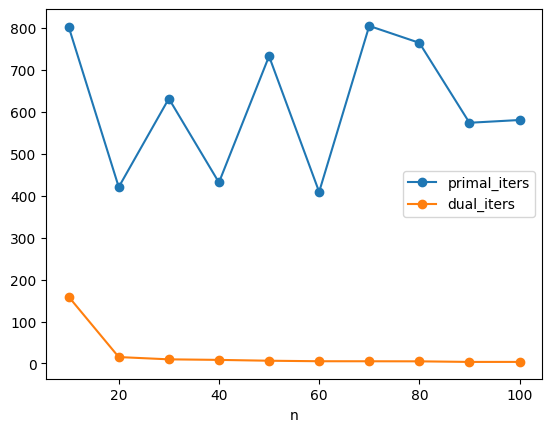

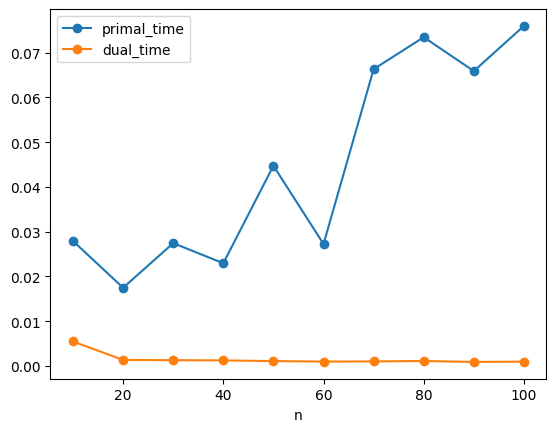

In [112]:
summary.plot(x="n", y=["primal_iters", "dual_iters"], marker="o")
summary.plot(x="n", y=["primal_time", "dual_time"], marker="o")

Для каплинга

In [113]:
df = pd.DataFrame(linear_coupling_results)

summary = df.groupby("n").agg({
    "primal_iters": "mean",
    "dual_iters": "mean",
    "primal_time": "mean",
    "dual_time": "mean",
    "primal_final_error": "mean",
    "dual_final_error": "mean",
    "primal_success": "mean",
    "dual_success": "mean"
}).reset_index()

summary

,n,primal_iters,dual_iters,primal_time,dual_time,primal_final_error,dual_final_error,primal_success,dual_success
0,10,6.08,8.76,0.001024,0.001049,0.044242,9.321986e-01,0.24,0.0
1,20,8.28,12.52,0.001448,0.001290,0.026504,4.454426e+00,0.12,0.0
2,30,8.52,13.72,0.001409,0.001221,0.122524,2.949863e+01,0.16,0.0
3,40,8.28,17.44,0.001642,0.001455,0.893448,3.958618e+01,0.04,0.0
4,50,5.36,16.20,0.001180,0.001514,0.777544,2.370241e+02,0.00,0.0
5,60,5.96,20.48,0.001381,0.001858,2.504056,2.484163e+04,0.00,0.0
6,70,7.84,21.00,0.001798,0.001784,2.029339,3.528441e+02,0.00,0.0
7,80,8.68,25.20,0.002061,0.002009,1.052082,2.319687e+03,0.04,0.0
8,90,7.92,27.72,0.002167,0.002258,0.625562,2.544065e+05,0.00,0.0
9,100,8.48,19.40,0.002446,0.001777,0.330415,5.822821e+06,0.00,0.0


<Axes: xlabel='n'>

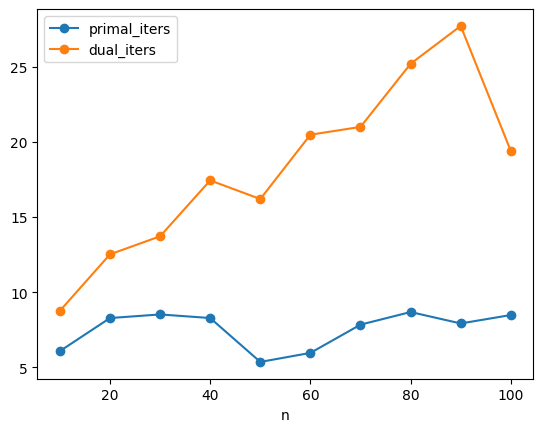

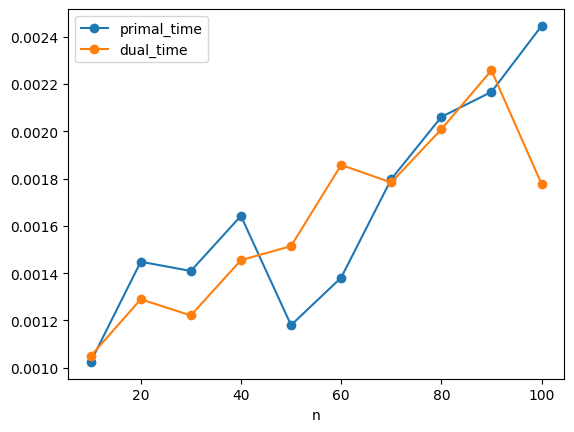

In [114]:
summary.plot(x="n", y=["primal_iters", "dual_iters"], marker="o")
summary.plot(x="n", y=["primal_time", "dual_time"], marker="o")